```bash
=============================================================================
AIR QUALITY DATA IMPUTATION 
=============================================================================
 STRATEGY (in order of preference):
  Priority | Method                  | Trigger Condition
 ----------|-------------------------|--------------------------------------------
    1      | Forward-fill (ffill)    | Rainfall columns only (cumulative nature)
    2      | Circular interpolation  | Wind direction (0–360° wrap-around)
    3      | Linear interpolation    | Gaps < 6 hrs (24 × 15min steps)
    4      | 1-hour rolling median   | Short isolated gaps after linear fails
    5      | Same time previous day  | Gaps 6–48 hrs (captures daily cycles)
    6      | Same time previous week | Gaps 2–7 days (captures weekly cycles)
    7      | Monthly × Hour median   | Large/seasonal gaps
    8      | Column-wide median      | Last resort — should rarely fire
=============================================================================
```

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
 
# Matplotlib / Seaborn style 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — CONFIGURATION (tune these without touching the logic below)
# ─────────────────────────────────────────────────────────────────────────────
# What: Central place to change thresholds.
# Why:  Avoids magic numbers scattered through the code.

# Gap limits (in number of 15-min intervals)
MAX_LINEAR_STEPS = 24  # 24 × 15 min = 6 hours
MAX_ROLLING_STEPS = 4  # 4  × 15 min = 1 hour

# Columns that are still too sparse after imputation — flag but keep
SPARSE_THRESHOLD = 0.50  # if > 50 % missing after all steps, warn the user

# Paths
ROOT_DIR = Path().cwd().parents[2]
DATASET_DIR = ROOT_DIR / "backend" / "data"
ARTIFACTS_DIR = DATASET_DIR / "artifacts"
MASTER_PATH = ARTIFACTS_DIR / "master_dataset.csv"
IMPUTED_PATH = ARTIFACTS_DIR / "final_master_dataset.csv"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — LOAD DATA & BASIC SANITY CHECKS
# What: Read the CSV and make sure time is parsed correctly.
# Why:  All time-based imputation breaks silently if "time" stays a string.
# ─────────────────────────────────────────────────────────────────────────────

master_df = pd.read_csv(MASTER_PATH)
master_df["time"] = pd.to_datetime(master_df["time"])
master_df = master_df.sort_values(["station_name", "time"]).reset_index(drop=True)

n_rows = len(master_df)
n_stations = master_df["station_name"].nunique()
date_min = master_df["time"].min()
date_max = master_df["time"].max()

print(f"Loaded {n_rows:,} rows | {n_stations} stations")
print(f"Date range: {date_min.date()} → {date_max.date()}")
print(f"Columns   : {list(master_df.columns)}")

Loaded 467,232 rows | 14 stations
Date range: 2025-01-01 → 2025-12-31
Columns   : ['time', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'xylene', 'o_xylene', 'ethyl_benzene', 'mp_xylene', 'average_temperature', 'relative_humidity', 'wind_speed', 'wind_direction', 'rainfall', 'total_rainfall', 'solar_radiation', 'pressure', 'vertical_wind_speed', 'station_name', 'site', 'org', 'latitude', 'longitude']


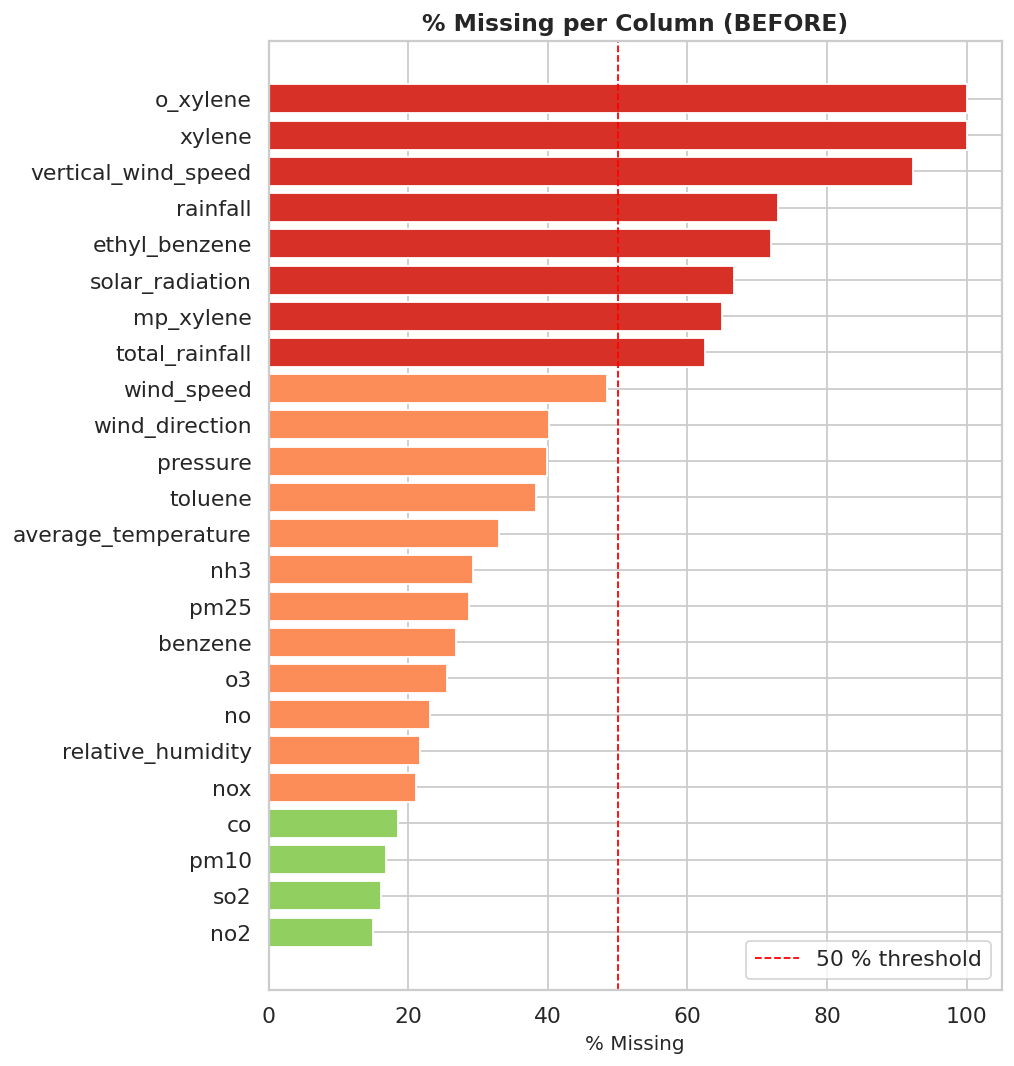

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/01_missing_before_bar.png


,pm25,pm10,no,no2,nox,nh3,so2,co,o3,benzene,...,wind_speed,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,vertical_wind_speed,site,latitude,longitude
station_name,,,,,,,,,,,,,,,,,,,,,
BapujiNagar,18.461758,17.896689,26.561073,20.316781,18.658676,20.305365,16.980594,25.616438,20.744863,17.522831,...,100.000000,15.393836,100.000000,100.0,100.000000,15.396689,100.000000,0.0,0.0,0.0
BtmLayout,7.251712,11.894977,16.840753,16.512557,16.261416,19.429224,8.213470,5.821918,5.191210,5.419521,...,5.539384,5.527968,100.000000,100.0,6.503995,4.977169,5.445205,0.0,0.0,0.0
BwssbKadabesanahalli,53.329918,46.559085,44.040301,43.545082,43.510929,44.245219,58.196721,43.750000,41.863046,44.467213,...,92.460724,92.460724,100.000000,100.0,76.835724,76.793033,76.741803,0.0,0.0,0.0
CityRailwayStation,100.000000,19.240868,19.009703,18.966895,18.966895,100.000000,19.397831,19.457763,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,0.0,0.0,0.0
Hebbal,10.222603,3.122146,100.000000,14.591895,100.000000,16.523973,14.888699,32.865297,8.518836,8.964041,...,4.200913,97.442922,100.000000,100.0,100.000000,100.000000,100.000000,0.0,0.0,0.0
HombegowdaNagar,5.436644,3.270548,13.869863,6.817922,6.835046,6.952055,12.517123,14.937215,8.079338,9.360731,...,100.000000,2.274543,100.000000,100.0,100.000000,2.271689,100.000000,0.0,0.0,0.0
Jayanagar5thBlock,9.737443,10.525114,29.366438,22.802511,22.699772,23.005137,14.029680,18.085046,9.543379,16.926370,...,100.000000,7.851027,100.000000,100.0,100.000000,9.897260,100.000000,0.0,0.0,0.0
Jigani,11.218607,9.155251,5.259703,5.122717,5.054224,5.105594,4.617580,3.969749,2.151826,7.003425,...,25.196918,24.874429,2.126142,0.0,24.255137,24.309361,100.000000,0.0,0.0,0.0
KasturiNagar,15.602169,16.429795,14.760274,14.757420,14.720320,14.777397,14.343607,9.997146,9.911530,22.186073,...,15.499429,15.490868,12.753995,0.0,15.462329,15.473744,100.000000,0.0,0.0,0.0


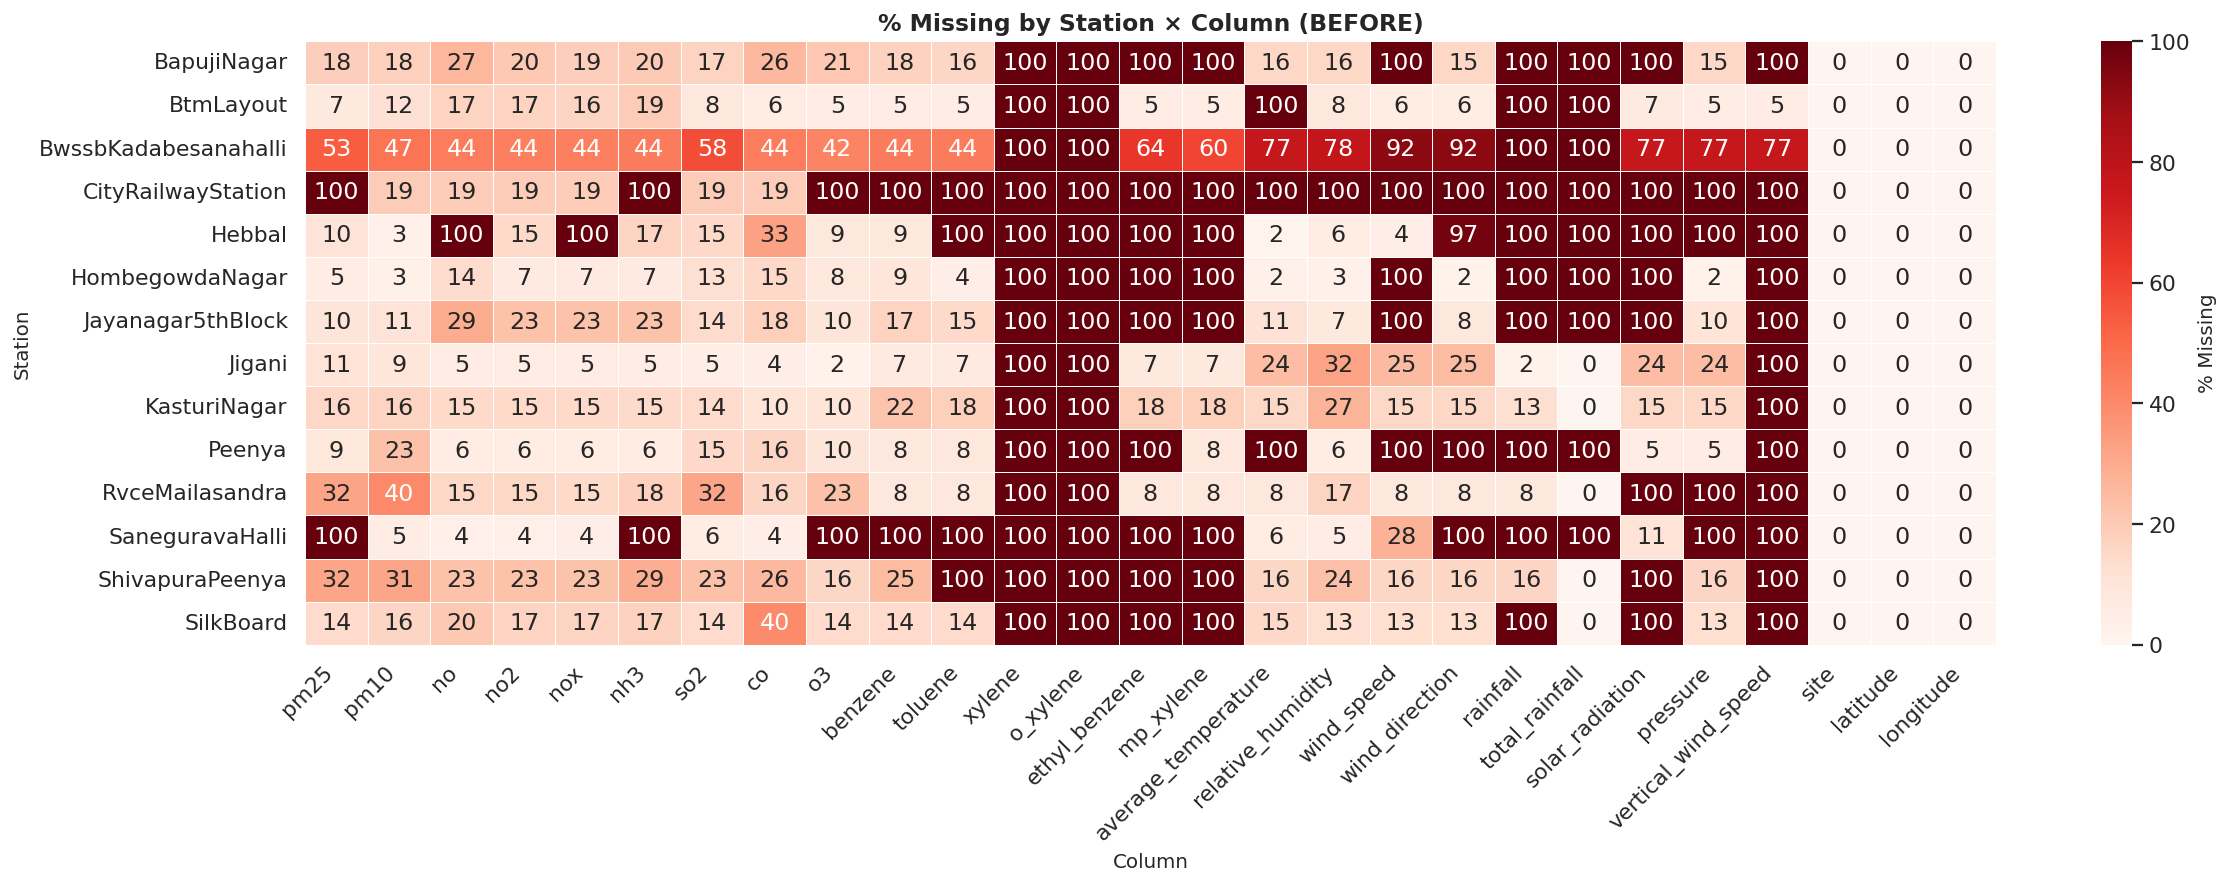

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/02_missing_before_heatmap.png


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — VISUALISE MISSING DATA (BEFORE)
# What: Plot a heatmap of % missing per column and station.
# Why:  Seeing the pattern helps decide which columns to drop vs impute.
# ─────────────────────────────────────────────────────────────────────────────

def plot_missing_heatmap(df, title, save_name):
    """
    Pivot to station × column and show % missing as a colour heatmap.
    Green = no missing, Red = 100 % missing.
    """
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    pivot = df.groupby("station_name")[numeric_cols].apply(
        lambda g: g.isna().mean() * 100
    )
    fig, ax = plt.subplots(
        figsize=(max(14, len(numeric_cols) * 0.7), max(6, n_stations * 0.5))
    )
    display(pivot)
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="Reds",  # red = missing, green = present
        vmin=0,
        vmax=100,
        linewidths=0.4,
        linecolor="white",
        annot=(pivot.shape[0] <= 20),  # show numbers only when ≤ 20 stations
        fmt=".0f",
        cbar_kws={"label": "% Missing"},
    )
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Station")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    path = PLOTS_DIR / save_name
    fig.savefig(path)
    plt.show()
    print(f"Saved → {path}")


def plot_missing_bar(df, title, save_name):
    """Overall % missing per column as a horizontal bar chart."""
    miss = df.isnull().mean().sort_values(ascending=False) * 100
    miss = miss[miss > 0]
    fig, ax = plt.subplots(figsize=(8, max(4, len(miss) * 0.35)))
    colors = ["#d73027" if v > 50 else "#fc8d59" if v > 20 else "#91cf60" for v in miss]
    ax.barh(miss.index[::-1], miss.values[::-1], color=colors[::-1], edgecolor="white")
    ax.set_xlabel("% Missing")
    ax.set_title(title)
    ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50 % threshold")
    ax.legend()
    plt.tight_layout()
    path = PLOTS_DIR / save_name
    fig.savefig(path)
    plt.show()
    print(f"Saved → {path}")


plot_missing_bar(
    master_df, "% Missing per Column (BEFORE)", "01_missing_before_bar.png"
)
plot_missing_heatmap(
    master_df, "% Missing by Station × Column (BEFORE)", "02_missing_before_heatmap.png"
)

Block 4 — Dropping columns: ['o_xylene', 'xylene', 'vertical_wind_speed', 'ethyl_benzene', 'mp_xylene']
Remaining columns: ['time', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'average_temperature', 'relative_humidity', 'wind_speed', 'wind_direction', 'rainfall', 'total_rainfall', 'solar_radiation', 'pressure', 'station_name', 'site', 'org', 'latitude', 'longitude']


,pm25,pm10,no,no2,nox,nh3,so2,co,o3,benzene,...,relative_humidity,wind_speed,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,site,latitude,longitude
station_name,,,,,,,,,,,,,,,,,,,,,
BapujiNagar,18.461758,17.896689,26.561073,20.316781,18.658676,20.305365,16.980594,25.616438,20.744863,17.522831,...,15.613584,100.000000,15.393836,100.000000,100.0,100.000000,15.396689,0.0,0.0,0.0
BtmLayout,7.251712,11.894977,16.840753,16.512557,16.261416,19.429224,8.213470,5.821918,5.191210,5.419521,...,7.514269,5.539384,5.527968,100.000000,100.0,6.503995,4.977169,0.0,0.0,0.0
BwssbKadabesanahalli,53.329918,46.559085,44.040301,43.545082,43.510929,44.245219,58.196721,43.750000,41.863046,44.467213,...,77.988388,92.460724,92.460724,100.000000,100.0,76.835724,76.793033,0.0,0.0,0.0
CityRailwayStation,100.000000,19.240868,19.009703,18.966895,18.966895,100.000000,19.397831,19.457763,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,0.0,0.0,0.0
Hebbal,10.222603,3.122146,100.000000,14.591895,100.000000,16.523973,14.888699,32.865297,8.518836,8.964041,...,5.770548,4.200913,97.442922,100.000000,100.0,100.000000,100.000000,0.0,0.0,0.0
HombegowdaNagar,5.436644,3.270548,13.869863,6.817922,6.835046,6.952055,12.517123,14.937215,8.079338,9.360731,...,3.079338,100.000000,2.274543,100.000000,100.0,100.000000,2.271689,0.0,0.0,0.0
Jayanagar5thBlock,9.737443,10.525114,29.366438,22.802511,22.699772,23.005137,14.029680,18.085046,9.543379,16.926370,...,7.051941,100.000000,7.851027,100.000000,100.0,100.000000,9.897260,0.0,0.0,0.0
Jigani,11.218607,9.155251,5.259703,5.122717,5.054224,5.105594,4.617580,3.969749,2.151826,7.003425,...,32.462900,25.196918,24.874429,2.126142,0.0,24.255137,24.309361,0.0,0.0,0.0
KasturiNagar,15.602169,16.429795,14.760274,14.757420,14.720320,14.777397,14.343607,9.997146,9.911530,22.186073,...,27.009132,15.499429,15.490868,12.753995,0.0,15.462329,15.473744,0.0,0.0,0.0


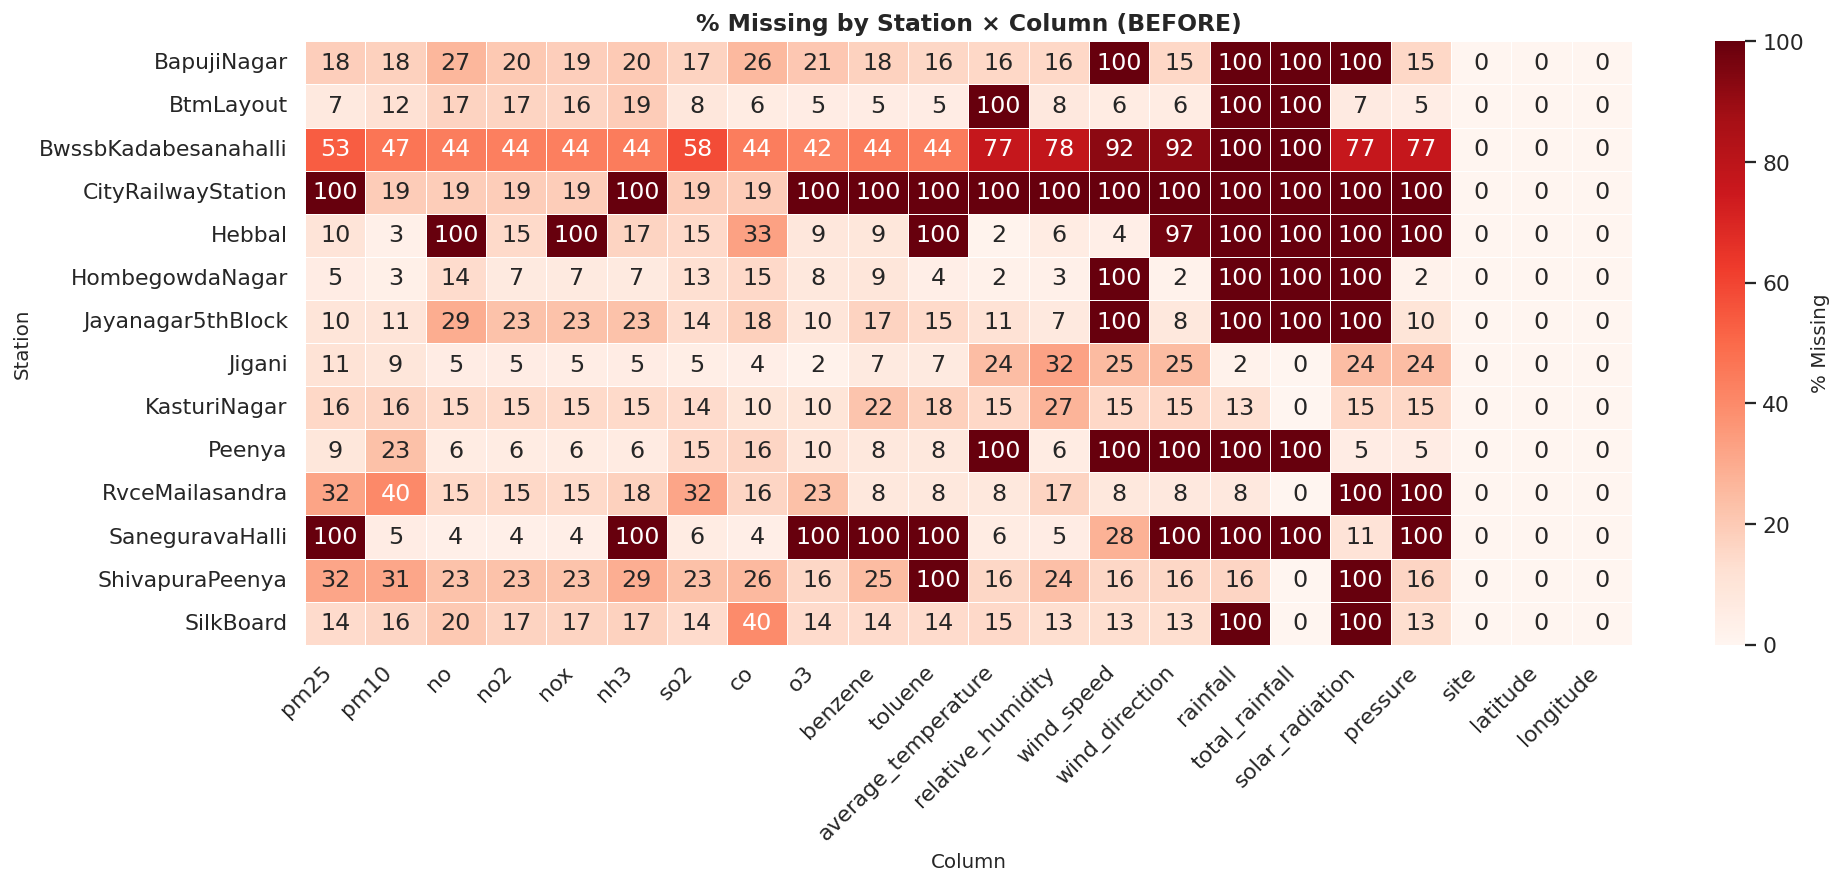

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/02_missing_before_heatmap.png


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — DROP UNRECOVERABLE COLUMNS
# What: Remove columns that are ≥ 90 % missing across ALL stations.
# Why:  Imputing >90 % of a column manufactures data, not recovers it.
# ─────────────────────────────────────────────────────────────────────────────
# Columns to DROP before any imputation (>90 % missing → not recoverable)
DROP_COLS = ["o_xylene", "xylene", "vertical_wind_speed","ethyl_benzene","mp_xylene"]
print(f"Block 4 — Dropping columns: {DROP_COLS}")
master_df = master_df.drop(columns=[c for c in DROP_COLS if c in master_df.columns])
print(f"Remaining columns: {list(master_df.columns)}")
plot_missing_heatmap(
    master_df, "% Missing by Station × Column (BEFORE)", "02_missing_before_heatmap.png"
)

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — HELPER FUNCTIONS
# What: Reusable functions that the main loop will call.
# Why:  Keeps the main loop clean and easy to read.
# ─────────────────────────────────────────────────────────────────────────────


def circular_interpolate(series: pd.Series) -> pd.Series:
    """
    Interpolate wind direction correctly across the 0–360° boundary.
    Naive linear interpolation on angles gives wrong results near 0/360.
    For example, midpoint between 350° and 10° should be 0°, not 180°.
    Fix: convert to sin/cos (cartesian), interpolate those, convert back.
    """
    rad = np.radians(series)
    sin_i = np.sin(rad).interpolate(method="linear", limit_direction="both")
    cos_i = np.cos(rad).interpolate(method="linear", limit_direction="both")
    return pd.Series(
        np.degrees(np.arctan2(sin_i, cos_i)) % 360,
        index=series.index,
    )


def count_remaining(df, cols):
    """Return total NaN count across given columns."""
    return df[cols].isna().sum().sum()

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — MAIN IMPUTATION LOOP (per station)
# What: For each station, apply imputation methods in priority order.
# Why:  Each station has an independent time-series; mixing stations would
#       introduce data from locations with different air-quality regimes.
#
# IMPORTANT: df.asfreq("15min") adds empty rows for any timestamp gaps
#            so the time index is perfectly regular before imputation starts.
# ─────────────────────────────────────────────────────────────────────────────

imputation_log = []  # records every imputed value: station, column, method, time
all_imputed = []  # collects the imputed df for each station

STATION_NAMES = master_df["station_name"].unique()
# Columns that behave differently from numeric sensors
CIRCULAR_COLS = ["wind_direction"]  # angles — need special interpolation
FFILL_COLS = ["rainfall", "total_rainfall"]  # cumulative — forward-fill then 0

for station in tqdm(STATION_NAMES, desc="Imputing stations"):
    print("Now working on station :", station)
    # ── Isolate this station ────────────────────────────────────────────────
    df = master_df[master_df["station_name"] == station].copy()
    df = df.set_index("time").sort_index()
    # ── Fill regular 15-min grid (adds NaN rows for missing timestamps) ─────
    df = df.asfreq("15min")
    # Non-numeric columns (like station_name, org, site) don't interpolate.
    # Forward-fill them so every new row has station metadata.
    meta_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    df[meta_cols] = df[meta_cols].ffill()
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    # ── Track null counts at each step (for this station) ───────────────────
    step_nulls = {"raw": df[numeric_cols].isna().sum().sum()}

    # ────────────────────────────────────────────────────────────────────────
    # STEP 1 — Forward-fill for cumulative rainfall columns
    # Why: rainfall is an accumulation; the last valid reading carries forward.
    # We fill 0 only if NO reading exists at all.
    # Time  | Raw Data | After .ffill()           | After .fillna(0) (Final)
    # 00:00 | NaN      | NaN (No previous value!) | 0.0 (Caught by fillna)
    # 00:15 | 1.2      | 1.2                      | 1.2
    # 00:30 | NaN      | 1.2 (Copied from 00:15)  | 1.2
    # 00:45 | 1.5      | 1.5                      | 1.5
    # ────────────────────────────────────────────────────────────────────────
    for col in FFILL_COLS:
        if col in df.columns:
            before = df[col].isna().sum()
            df[col] = df[col].ffill().fillna(0)
            filled = before - df[col].isna().sum()
            if filled:
                imputation_log.append(
                    dict(station=station, col=col, method="ffill", n_filled=filled)
                )

    # ────────────────────────────────────────────────────────────────────────
    # STEP 2 — Circular interpolation for wind direction
    # Why: Wind direction wraps at 360°; standard interpolation breaks there.
    # ────────────────────────────────────────────────────────────────────────
    for col in CIRCULAR_COLS:
        if col in df.columns and df[col].isna().sum() > 0:
            before = df[col].isna().sum()
            df[col] = circular_interpolate(df[col])
            filled = before - df[col].isna().sum()
            if filled:
                imputation_log.append(
                    dict(
                        station=station,
                        col=col,
                        method="circular_interp",
                        n_filled=filled,
                    )
                )

    # ────────────────────────────────────────────────────────────────────────
    # STEP 3 — Linear interpolation (gaps ≤ 6 hours = 24 steps)
    # Why: For short gaps, adjacent sensor readings give a smooth and physically meaningful estimate.
    # limit=24 means at most 24 consecutive NaNs are filled.
    # ────────────────────────────────────────────────────────────────────────
    remaining_cols = [c for c in numeric_cols if c not in FFILL_COLS + CIRCULAR_COLS]
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        before = df[col].isna().sum()
        df[col] = df[col].interpolate(method="linear", limit=MAX_LINEAR_STEPS)
        filled = before - df[col].isna().sum()
        if filled:
            imputation_log.append(
                dict(station=station, col=col, method="linear_interp", n_filled=filled)
            )
    step_nulls["after_linear"] = df[numeric_cols].isna().sum().sum()

    # ────────────────────────────────────────────────────────────────────────
    # STEP 4 — 1-hour rolling median (isolated spikes still missing)
    # Why: Some single points remain after linear interpolation because they
    #      sit at the edge of a gap where one side has no valid data.
    #      The recent 1-hour window gives a local reference.
    # ────────────────────────────────────────────────────────────────────────
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        # Compute rolling median over past 1 hour (4 steps, min 1 valid point)
        rolling_med = df[col].rolling(window=MAX_ROLLING_STEPS, min_periods=1).median()
        missing_mask = df[col].isna()
        df.loc[missing_mask, col] = rolling_med[missing_mask]
        filled = missing_mask.sum() - df[col].isna().sum()
        if filled:
            imputation_log.append(
                dict(
                    station=station,
                    col=col,
                    method="rolling_1h_median",
                    n_filled=filled,
                )
            )
    step_nulls["after_rolling"] = df[numeric_cols].isna().sum().sum()

    # ────────────────────────────────────────────────────────────────────────
    # STEP 5 — Same time, previous day (gap 6–48 hrs)
    # Why: Air quality follows strong daily cycles (morning rush, night dip).
    # Yesterday at the same hour is a better estimate than a global median.
    # ────────────────────────────────────────────────────────────────────────
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        n_filled = 0
        for idx in df[df[col].isna()].index:
            prev = idx - pd.Timedelta(days=1)
            if prev in df.index and pd.notna(df.loc[prev, col]):
                df.loc[idx, col] = df.loc[prev, col]
                n_filled += 1
        if n_filled:
            imputation_log.append(
                dict(station=station, col=col, method="prev_day", n_filled=n_filled)
            )
    step_nulls["after_prev_day"] = df[numeric_cols].isna().sum().sum()

    # ────────────────────────────────────────────────────────────────────────
    # STEP 6 — Same time, previous week (gap 2–7 days)
    # Why: Weekly patterns matter too (weekday vs weekend traffic/industry).
    # ────────────────────────────────────────────────────────────────────────
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        n_filled = 0
        for idx in df[df[col].isna()].index:
            prev = idx - pd.Timedelta(days=7)
            if prev in df.index and pd.notna(df.loc[prev, col]):
                df.loc[idx, col] = df.loc[prev, col]
                n_filled += 1
        if n_filled:
            imputation_log.append(
                dict(station=station, col=col, method="prev_week", n_filled=n_filled)
            )

    step_nulls["after_prev_week"] = df[numeric_cols].isna().sum().sum()

    # ────────────────────────────────────────────────────────────────────────
    # STEP 7 — Monthly × Hour median
    # Why: For gaps longer than a week, the best available signal is the
    #      typical value for that calendar month and hour of day.
    #      This handles seasonal variation (e.g., summer O₃ peaks).
    # ────────────────────────────────────────────────────────────────────────
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        # Build a lookup: {(month, hour): median_value}
        medians = df.groupby([df.index.month, df.index.hour])[col].median()
        n_filled = 0
        for idx in df[df[col].isna()].index:
            key = (idx.month, idx.hour)
            if key in medians.index and pd.notna(medians[key]):
                df.loc[idx, col] = medians[key]
                n_filled += 1
        if n_filled:
            imputation_log.append(
                dict(
                    station=station,
                    col=col,
                    method="month_hour_median",
                    n_filled=n_filled,
                )
            )

    step_nulls["after_month_hour"] = df[numeric_cols].isna().sum().sum()

    # ────────────────────────────────────────────────────────────────────────
    # STEP 8 — Column-wide median (last resort)
    # Why: If a column is missing for an entire station for an extended period,
    #      none of the time-aware methods can help.
    #      The column median is the safest flat-line fallback.
    # ────────────────────────────────────────────────────────────────────────
    for col in remaining_cols:
        n = df[col].isna().sum()
        if n == 0:
            continue
        median_val = df[col].median()
        if pd.isna(median_val):
            # Column is 100 % missing for this station — fill with 0
            median_val = 0.0
        df[col] = df[col].fillna(median_val)
        imputation_log.append(
            dict(station=station, col=col, method="col_median", n_filled=n)
        )
        print(f" {station} | {col}: used column median ({median_val:.2f}) for {n} gaps")

    step_nulls["after_col_median"] = df[numeric_cols].isna().sum().sum()

    # ── Warn if column is still very sparse ─────────────────────────────────
    still_missing = df[numeric_cols].isna().mean()
    sparse = still_missing[still_missing > SPARSE_THRESHOLD]
    if not sparse.empty:
        print(f"SPARSE columns in {station} (>50% missing even after imputation):")
        print(sparse.round(2).to_string())

    df_out = df.reset_index()
    all_imputed.append(df_out)

Imputing stations:   0%|          | 0/14 [00:00<?, ?it/s]

Now working on station : BapujiNagar


Imputing stations:   7%|▋         | 1/14 [00:20<04:22, 20.17s/it]

 BapujiNagar | wind_speed: used column median (0.00) for 35040 gaps
 BapujiNagar | solar_radiation: used column median (0.00) for 35040 gaps
Now working on station : BtmLayout


Imputing stations:  14%|█▍        | 2/14 [00:28<02:35, 13.00s/it]

...

 SaneguravaHalli | pm25: used column median (0.00) for 35040 gaps
 SaneguravaHalli | nh3: used column median (0.00) for 35040 gaps
 SaneguravaHalli | o3: used column median (0.00) for 35040 gaps
 SaneguravaHalli | benzene: used column median (0.00) for 35040 gaps
 SaneguravaHalli | toluene: used column median (0.00) for 35040 gaps
 SaneguravaHalli | pressure: used column median (0.00) for 35040 gaps
SPARSE columns in SaneguravaHalli (>50% missing even after imputation):
wind_direction    1.0
Now working on station : ShivapuraPeenya


Imputing stations:  93%|█████████▎| 13/14 [03:32<00:17, 17.98s/it]

 ShivapuraPeenya | toluene: used column median (0.00) for 35040 gaps
 ShivapuraPeenya | solar_radiation: used column median (0.00) for 35040 gaps
Now working on station : SilkBoard


Imputing stations: 100%|██████████| 14/14 [03:40<00:00, 15.77s/it]

 SilkBoard | solar_radiation: used column median (0.00) for 35040 gaps


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 — COMBINE & SAVE
# What: Stack all per-station DataFrames back into one master DataFrame.
# Why:  Downstream modelling expects a single CSV.
# ─────────────────────────────────────────────────────────────────────────────
 
final_df = pd.concat(all_imputed, ignore_index=True)
final_df.to_csv(IMPUTED_PATH, index=False)
 
print(f"Block 7 — Saved imputed dataset → {IMPUTED_PATH}")
print(f"Original rows : {len(master_df):,}")
print(f"Imputed  rows : {len(final_df):,}  (extra rows = timestamps filled by asfreq)")


Block 7 — Saved imputed dataset → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/final_master_dataset.csv
Original rows : 467,232
Imputed  rows : 467,232  (extra rows = timestamps filled by asfreq)


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — IMPUTATION LOG ANALYSIS
# What: Turn the log list into a DataFrame and print a clear summary.
# Why:  Helps you understand HOW each gap was filled (trust the numbers).
# ─────────────────────────────────────────────────────────────────────────────

log_df = pd.DataFrame(imputation_log)
print("Imputation log — total fills by method:")
print(
    log_df.groupby("method")["n_filled"].sum().sort_values(ascending=False).to_string()
)
print("Imputation log — total fills by column (top 15):")
print(log_df.groupby("col")["n_filled"].sum().nlargest(15).to_string())


Imputation log — total fills by method:
method
col_median           1300680
ffill                 632702
prev_day              521410
linear_interp         327425
circular_interp        82816
month_hour_median      26544
rolling_1h_median      15088
Imputation log — total fills by column (top 15):
col
rainfall               340670
solar_radiation        311180
total_rainfall         292032
wind_speed             226255
pressure               186588
toluene                178786
average_temperature    154367
nh3                    137007
pm25                   134078
benzene                125201
o3                     119647
no                     108168
relative_humidity      101217
nox                     98680
co                      86703


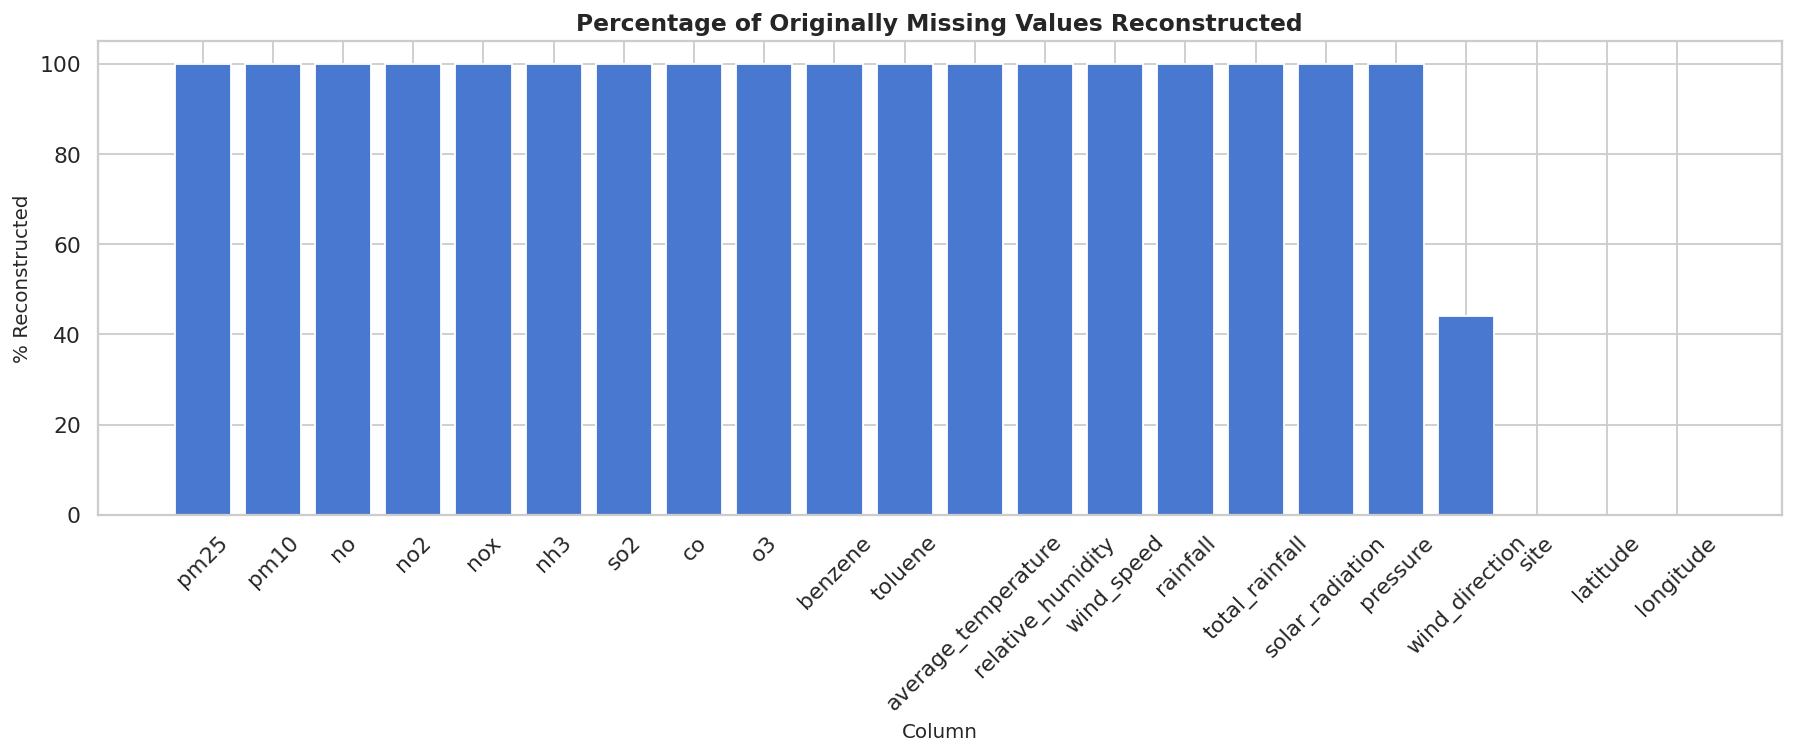

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/04_reconstructed_percentage.png


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = master_df.select_dtypes(include=np.number).columns

before_missing = master_df[numeric_cols].isna().sum()
after_missing = final_df[numeric_cols].isna().sum()

reconstructed = before_missing - after_missing
reconstructed_pct = (reconstructed / before_missing.replace(0, np.nan)) * 100
reconstructed_pct = (
    reconstructed_pct.replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(reconstructed_pct.index, reconstructed_pct.values)

ax.set_title("Percentage of Originally Missing Values Reconstructed")
ax.set_ylabel("% Reconstructed")
ax.set_xlabel("Column")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
path = PLOTS_DIR / "04_reconstructed_percentage.png"
fig.savefig(path, dpi=300)
plt.show()
print(f"Saved → {path}")

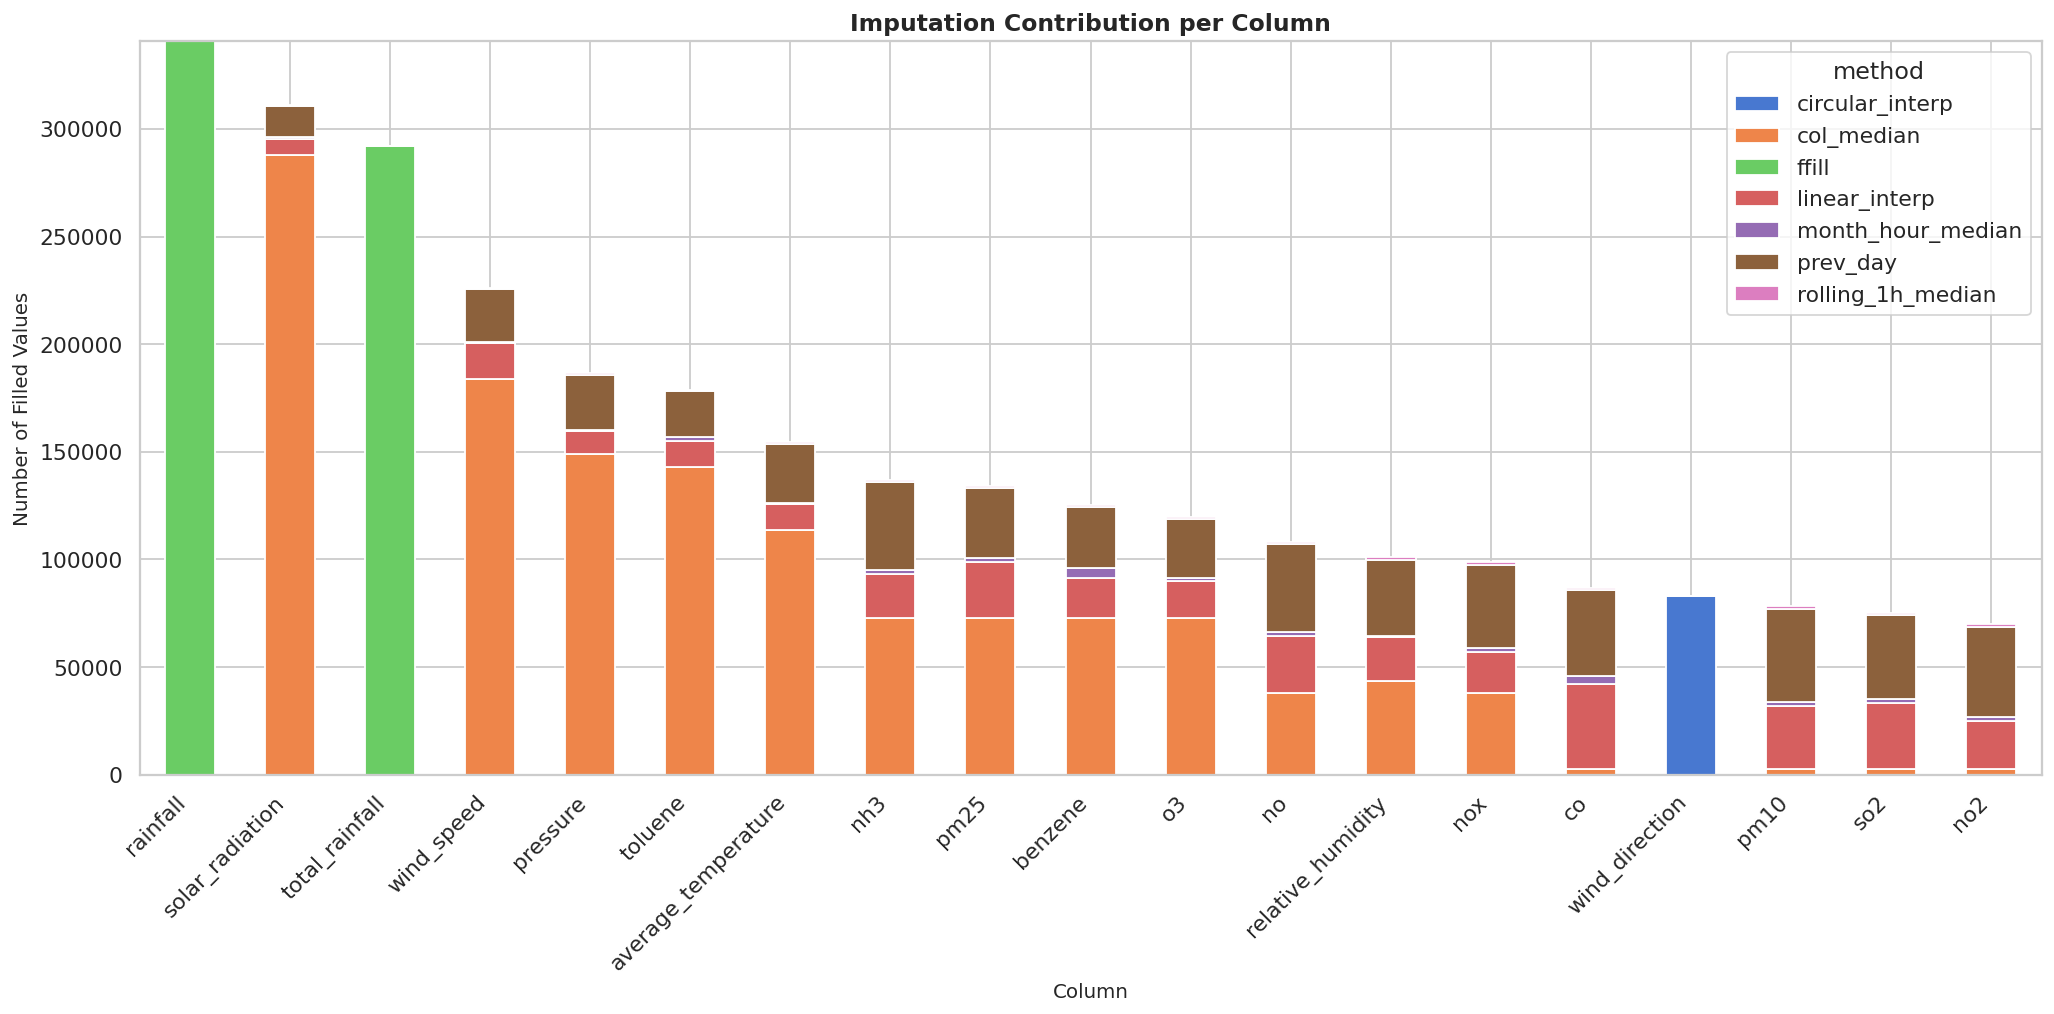

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/05_imputation_stacked_by_column.png


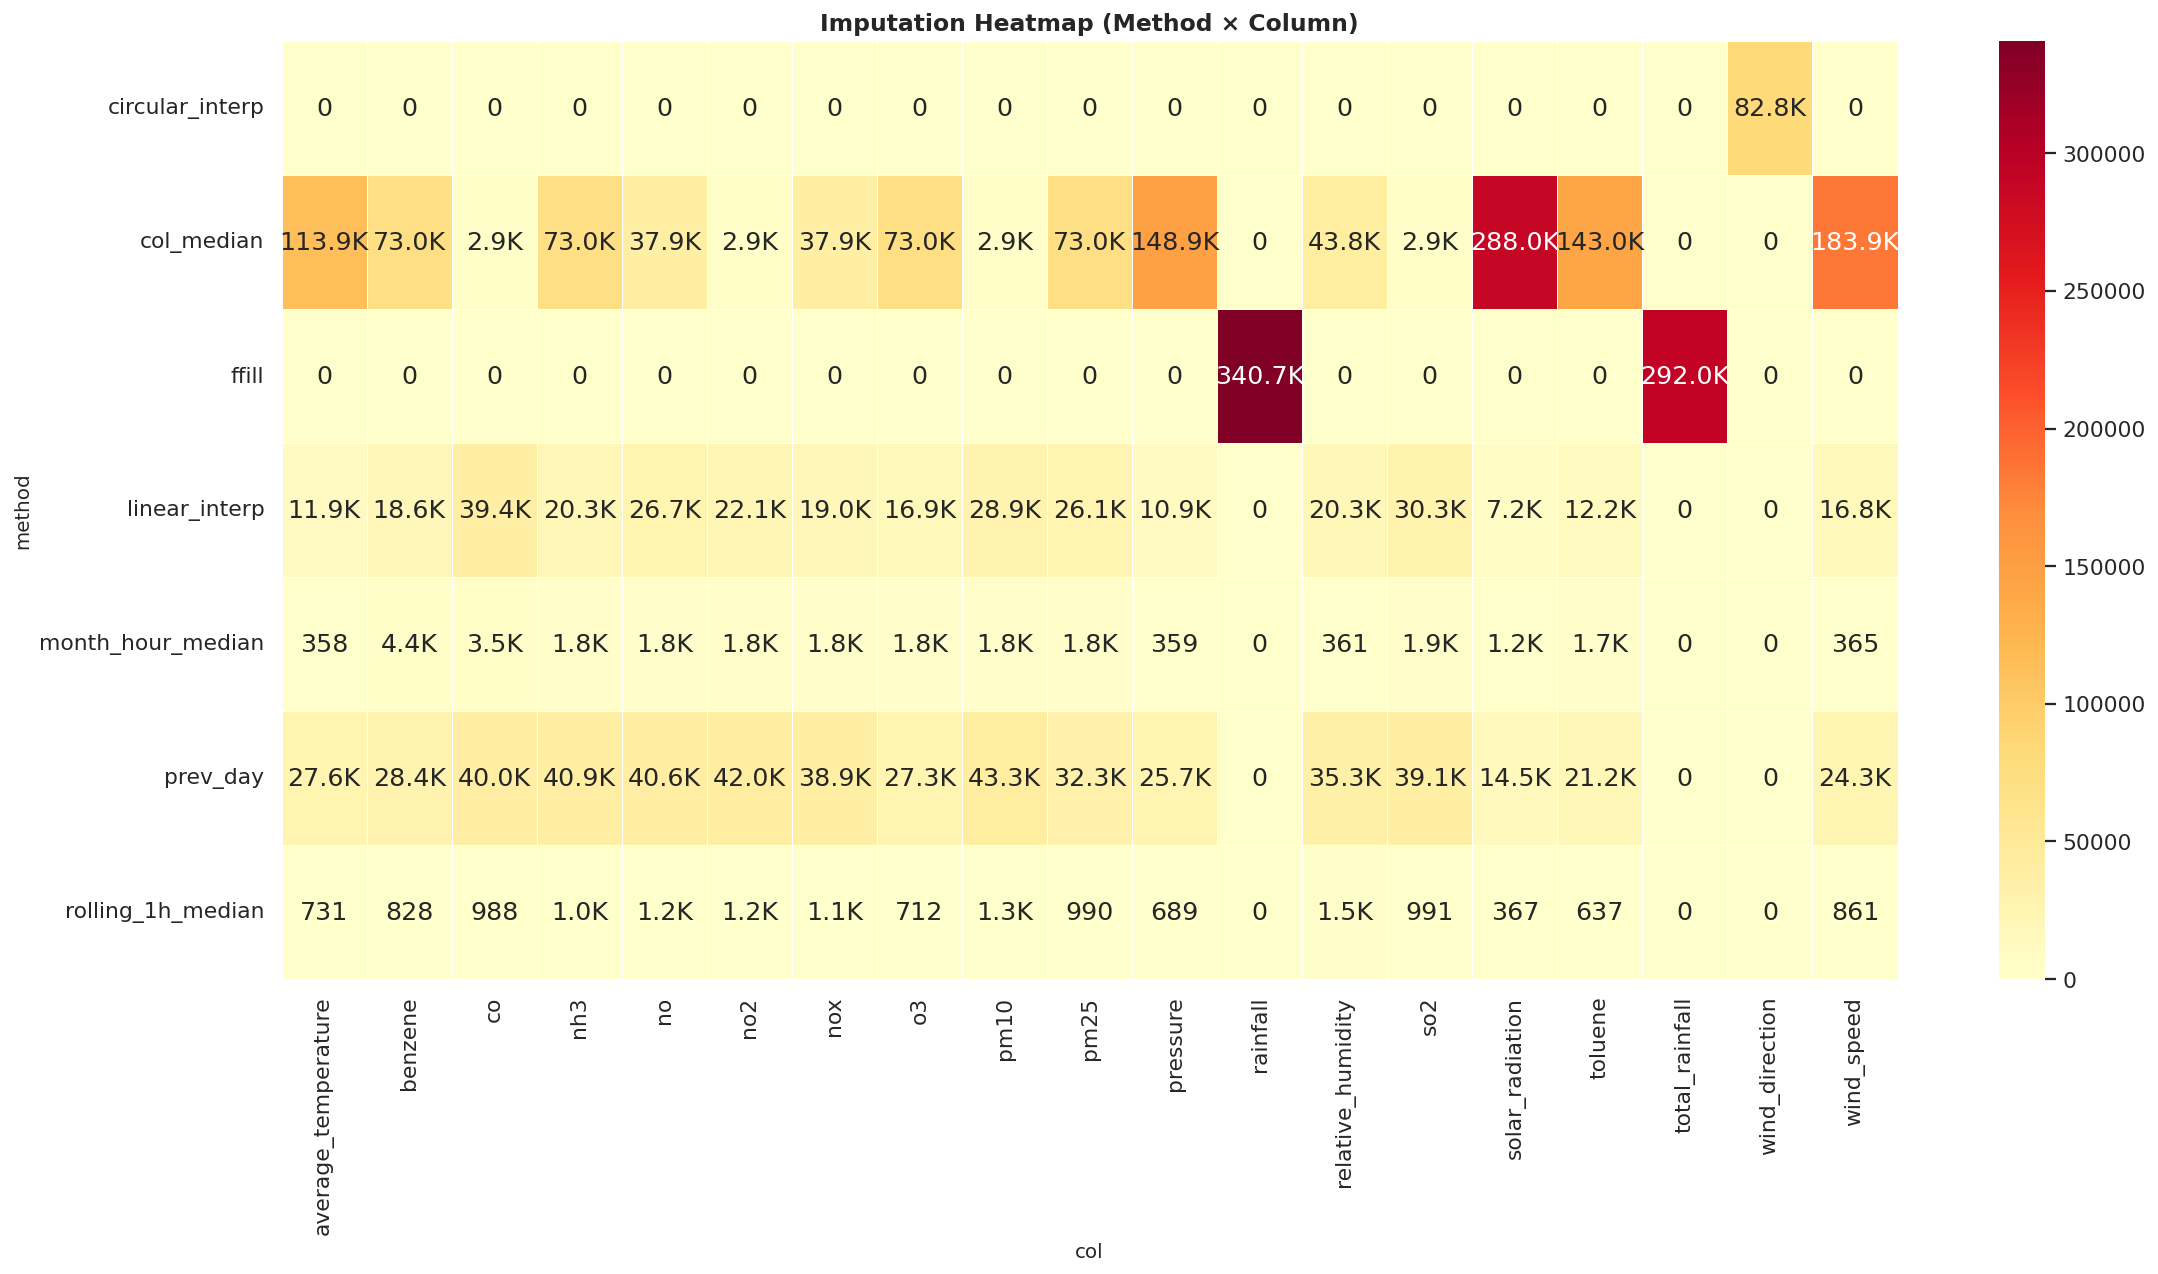

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/06_imputation_heatmap.png


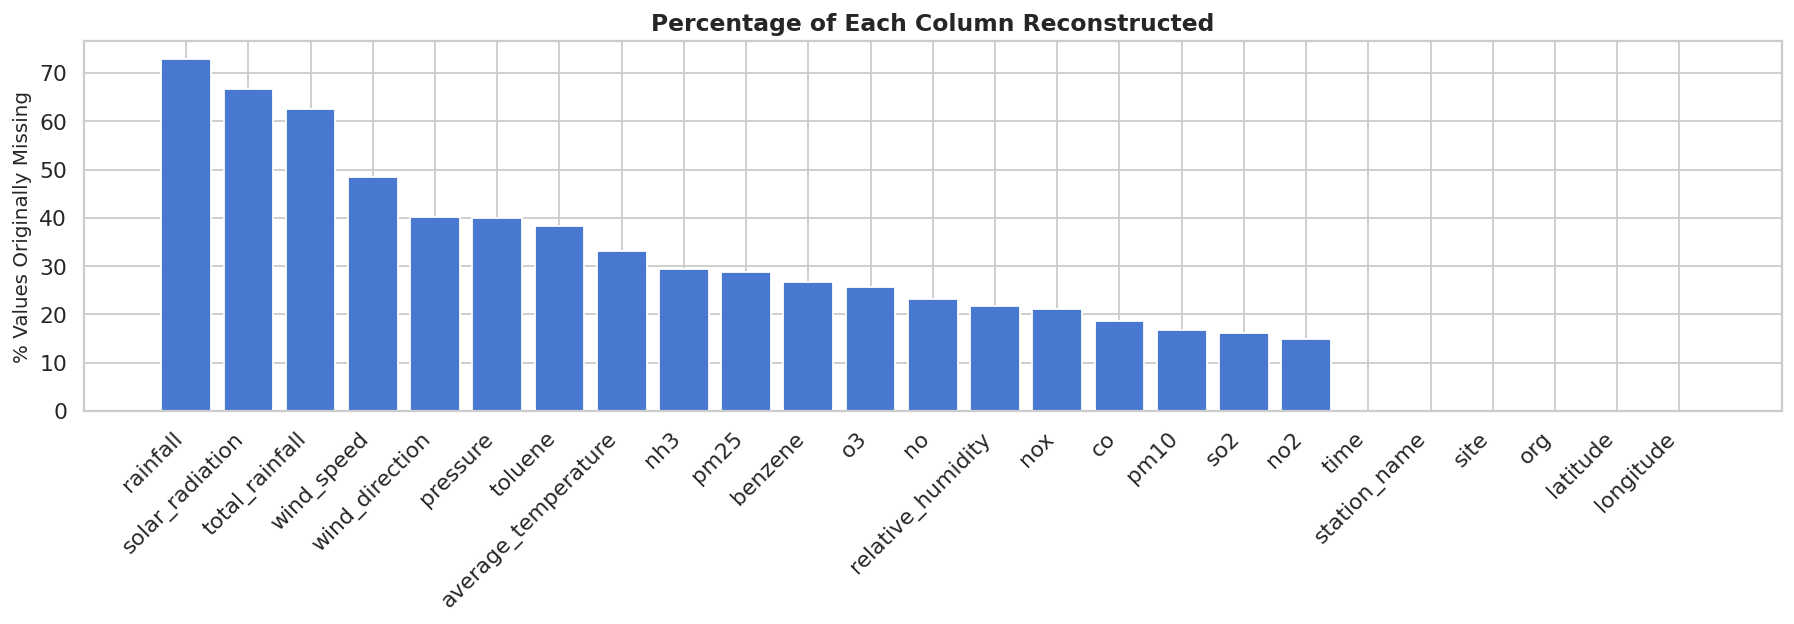

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/07_reconstructed_percentage.png


In [38]:
# ─────────────────────────────────────────────────────────────
# BLOCK 10 — ADVANCED IMPUTATION VISUALIZATION
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

log_df = pd.DataFrame(imputation_log)

# ============================================================
# 10A — STACKED BAR:
# How much each method filled for each column
# ============================================================
method_col = log_df.groupby(["col", "method"])["n_filled"].sum().unstack(fill_value=0)

# Sort columns by total fills
method_col["TOTAL"] = method_col.sum(axis=1)
method_col = method_col.sort_values("TOTAL", ascending=False)
method_col = method_col.drop(columns="TOTAL")

fig, ax = plt.subplots(figsize=(16, 8))
method_col.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)
ax.set_title("Imputation Contribution per Column")
ax.set_ylabel("Number of Filled Values")
ax.set_xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
path = PLOTS_DIR / "05_imputation_stacked_by_column.png"
plt.savefig(path, dpi=300)
plt.show()
print(f"Saved → {path}")

# ============================================================
# 10B — HEATMAP:
# Method × Column fill intensity
# ============================================================
heatmap_data = log_df.groupby(["method", "col"])["n_filled"].sum().unstack(fill_value=0)

def human_format(num):
    if num >= 1_000_000:
        return f"{num / 1_000_000:.1f}M"
    elif num >= 1_000:
        return f"{num / 1_000:.1f}K"
    else:
        return f"{num:.0f}"


# Convert annotations separately
annot_data = np.vectorize(human_format)(heatmap_data.values)
fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    heatmap_data,
    annot=annot_data,  # use formatted strings
    fmt="",  # IMPORTANT: disable numeric fmt
    cmap="YlOrRd",
    linewidths=0.5,
    annot_kws={"size": 14},
    ax=ax,
)
ax.set_title("Imputation Heatmap (Method × Column)")
plt.tight_layout()
path = PLOTS_DIR / "06_imputation_heatmap.png"
plt.savefig(path, dpi=300)
plt.show()
print(f"Saved → {path}")

# ============================================================
# 10C — PERCENTAGE OF COLUMN RECONSTRUCTED
# ============================================================

original_missing = master_df.isna().sum()
reconstructed_pct = (original_missing / len(master_df)) * 100

reconstructed_pct = reconstructed_pct.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    reconstructed_pct.index,
    reconstructed_pct.values,
)
ax.set_title("Percentage of Each Column Reconstructed")
ax.set_ylabel("% Values Originally Missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
path = PLOTS_DIR / "07_reconstructed_percentage.png"
plt.savefig(path, dpi=300)
plt.show()
print(f"Saved → {path}")


 Block 10 — Imputation dashboard…


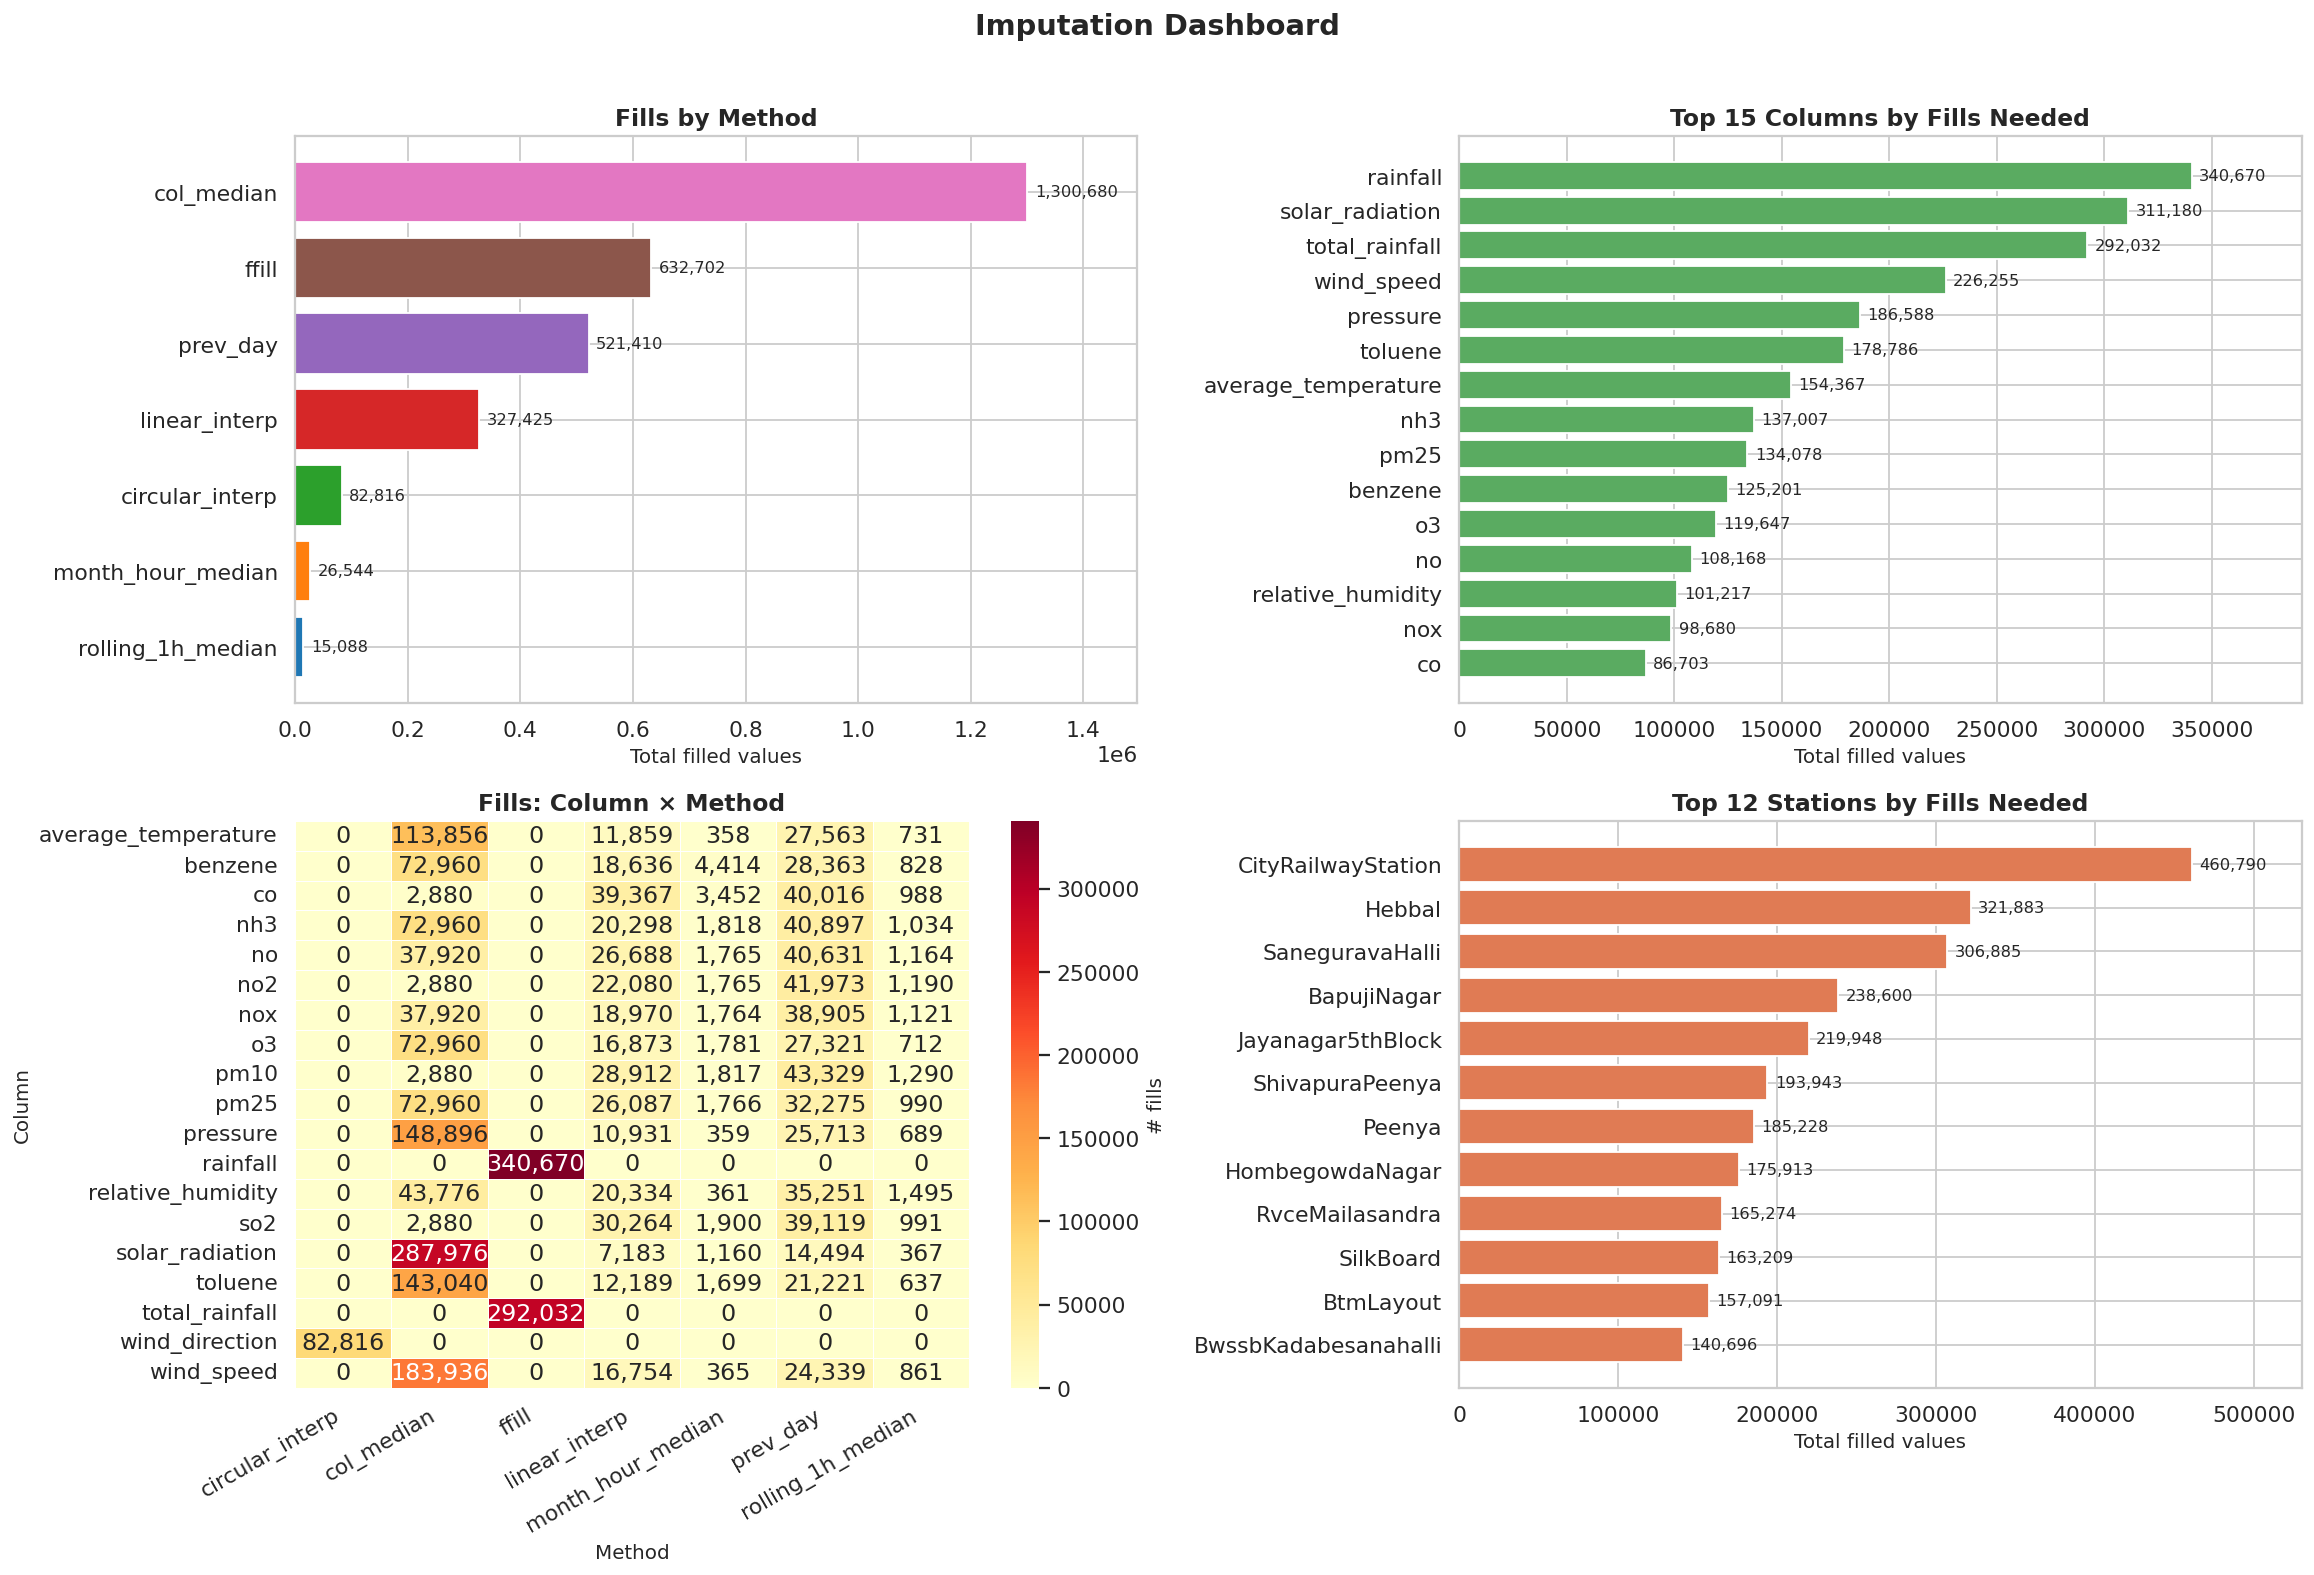

   Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/05_imputation_dashboard.png


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 — IMPUTATION DASHBOARD (matplotlib)
# ─────────────────────────────────────────────────────────────────────────────
# What: 4-panel summary of the imputation log.
# Why:  Quick visual audit — which methods fired most, which columns needed
#       the most help, how fills were distributed across stations.
 
print("\n Block 10 — Imputation dashboard…")
 
method_counts = log_df.groupby("method")["n_filled"].sum().sort_values(ascending=False)
col_counts    = log_df.groupby("col")["n_filled"].sum().nlargest(15).sort_values(ascending=False)
station_counts = log_df.groupby("station")["n_filled"].sum().nlargest(12).sort_values(ascending=False)
 
# Pivot: column × method heatmap
pivot = (
    log_df.groupby(["col", "method"])["n_filled"]
    .sum()
    .unstack(fill_value=0)
)
 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Imputation Dashboard", fontsize=16, fontweight="bold", y=1.01)
 
PALETTE = sns.color_palette("tab10", n_colors=10)
 
# Panel 1 — Method usage
ax = axes[0, 0]
bars = ax.barh(method_counts.index[::-1], method_counts.values[::-1],
               color=PALETTE[:len(method_counts)], edgecolor="white")
ax.set_xlabel("Total filled values")
ax.set_title("Fills by Method")
for bar, val in zip(bars, method_counts.values[::-1]):
    ax.text(bar.get_width() + max(method_counts) * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.margins(x=0.15)
 
# Panel 2 — Top columns
ax = axes[0, 1]
bars = ax.barh(col_counts.index[::-1], col_counts.values[::-1],
               color="#5aab61", edgecolor="white")
ax.set_xlabel("Total filled values")
ax.set_title("Top 15 Columns by Fills Needed")
for bar, val in zip(bars, col_counts.values[::-1]):
    ax.text(bar.get_width() + max(col_counts) * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.margins(x=0.15)
 
# Panel 3 — Heatmap: column × method
ax = axes[1, 0]
if not pivot.empty:
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        fmt=",d",
        annot=pivot.shape[0] <= 20,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "# fills"},
    )
ax.set_title("Fills: Column × Method")
ax.set_xlabel("Method")
ax.set_ylabel("Column")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
 
# Panel 4 — Top stations
ax = axes[1, 1]
bars = ax.barh(station_counts.index[::-1], station_counts.values[::-1],
               color="#e07b54", edgecolor="white")
ax.set_xlabel("Total filled values")
ax.set_title("Top 12 Stations by Fills Needed")
for bar, val in zip(bars, station_counts.values[::-1]):
    ax.text(bar.get_width() + max(station_counts) * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.margins(x=0.15)
 
plt.tight_layout()
path = PLOTS_DIR / "05_imputation_dashboard.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"   Saved → {path}")
 


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

DIST_DIR = PLOTS_DIR / "station_distributions"
DIST_DIR.mkdir(exist_ok=True)

# Numeric columns only
numeric_cols = master_df.select_dtypes(include=np.number).columns.tolist()

# Optional: remove identifiers
exclude_cols = ["site", "latitude", "longitude"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

stations = sorted(master_df["station_name"].dropna().unique())

for station in stations:
    print(f"\nPlotting distributions for: {station}")
    before_df = master_df[master_df["station_name"] == station]
    after_df = final_df[final_df["station_name"] == station]
    n_cols = 2
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4 * n_rows),
    )
    axes = np.array(axes).flatten()
    for i, col in enumerate(numeric_cols):
        ax = axes[i]

        before_vals = before_df[col].dropna()
        after_vals = after_df[col].dropna()

        # Skip completely empty columns
        if len(before_vals) == 0 and len(after_vals) == 0:
            ax.set_visible(False)
            continue

        # BEFORE
        if len(before_vals) > 0:
            sns.kdeplot(
                before_vals,
                ax=ax,
                label="Before",
                linewidth=2,
            )

        # AFTER
        if len(after_vals) > 0:
            sns.kdeplot(
                after_vals,
                ax=ax,
                label="After",
                linewidth=2,
                linestyle="--",
            )

        ax.set_title(col)
        ax.legend()

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(
        f"Distribution Comparison — {station}",
        fontsize=18,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    save_path = DIST_DIR / f"{station}_distribution_compare.png"
    fig.savefig(save_path, dpi=300)
    plt.close(fig)
    print(f"Saved → {save_path}")


 Block 11 — Spot-check for 'CityRailwayStation' | 'average_temperature'


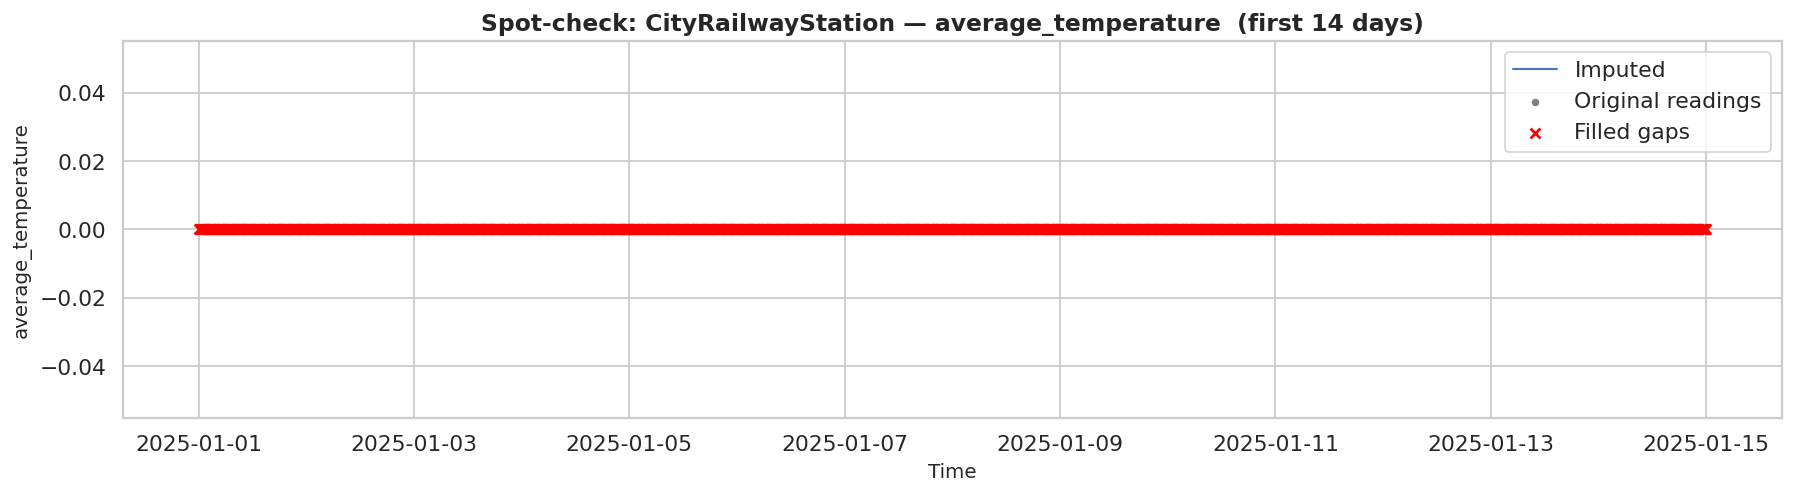

   Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/06_spotcheck_CityRailwayStation_average_temperature.png

 All blocks complete!
   Imputed CSV  : /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/final_master_dataset.csv
   Plots folder : /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 — SPOT-CHECK: BEFORE vs AFTER TIME SERIES (pick any station/column)
# ─────────────────────────────────────────────────────────────────────────────
# What: Overlay the original (with gaps) and imputed values for one station.
# Why:  Visually confirms the imputed values look reasonable — not spiky or flat.
 
def plot_spot_check(raw_df, imp_df, station, col, days=14):
    """
    Plot 'days' of data for one station × column.
    Grey dots = original data, blue line = imputed, red X = filled gaps.
    """
    raw_s = raw_df[raw_df["station_name"] == station].set_index("time")[col].sort_index()
    imp_s = imp_df[imp_df["station_name"] == station].set_index("time")[col].sort_index()
 
    # Restrict to first 'days' days of data
    start = imp_s.index.min()
    end   = start + pd.Timedelta(days=days)
    raw_s = raw_s.loc[start:end]
    imp_s = imp_s.loc[start:end]
 
    was_null = raw_s.isna() & imp_s.notna()  # positions that were filled
 
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(imp_s.index, imp_s.values, color="#4878d0", lw=1.2, label="Imputed", zorder=2)
    ax.scatter(raw_s.index, raw_s.values, color="grey", s=10, zorder=3, label="Original readings")
    ax.scatter(imp_s[was_null].index, imp_s[was_null].values,
               color="red", marker="x", s=30, zorder=4, label="Filled gaps")
    ax.set_title(f"Spot-check: {station} — {col}  (first {days} days)")
    ax.set_xlabel("Time")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")
    plt.tight_layout()
    safe_name = station.replace(" ", "_").replace("/", "_")
    path = PLOTS_DIR / f"06_spotcheck_{safe_name}_{col}.png"
    fig.savefig(path)
    plt.show()
    print(f"   Saved → {path}")
 
# Auto-pick: station with most fills, column that had most fills in that station
top_station = log_df.groupby("station")["n_filled"].sum().idxmax()
top_col     = log_df[log_df["station"] == top_station].groupby("col")["n_filled"].sum().idxmax()
 
print(f"\n Block 11 — Spot-check for '{top_station}' | '{top_col}'")
plot_spot_check(master_df, final_df, top_station, top_col, days=14)
 
print("\n All blocks complete!")
print(f"   Imputed CSV  : {IMPUTED_PATH}")
print(f"   Plots folder : {PLOTS_DIR}")
